<a id = "6" ></a>
# <span style="font-family:serif; font-size:28px;"> 1. Импорт библиотек + вводная обработка </span>
<a id = "Undertanding the data" ></a>

In [22]:


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/fedesoriano/heart-failure-prediction/heart.csv


In [25]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt


In [23]:
from sklearn.model_selection import train_test_split


In [26]:
df = pd.read_csv("/kaggle/input/datasets/fedesoriano/heart-failure-prediction/heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [27]:
x=df.drop(columns="HeartDisease")
y = df["HeartDisease"]

x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size=0.2,
    stratify=y, 
    random_state=42
)

<a id = "6" ></a>
# <span style="font-family:serif; font-size:28px;"> 2. Описание признаков + деление на типы данных </span>
<a id = "Undertanding the data" ></a>

## Описание признаков датасета

| Признак | Описание |
|-------|----------|
| Age | Возраст пациента (в годах) |
| Sex | Пол пациента (M — мужчина, F — женщина) |
| ChestPainType | Тип боли в груди (TA — типичная стенокардия, ATA — атипичная стенокардия, NAP — боль не связанная со стенокардией, ASY — бессимптомное состояние) |
| RestingBP | Артериальное давление пациента в состоянии покоя (мм рт. ст.) |
| Cholesterol | Уровень холестерина в крови (мг/дл) |
| FastingBS | Уровень сахара в крови натощак (1 — если уровень сахара > 120 мг/дл, 0 — иначе) |
| RestingECG | Результаты электрокардиограммы в состоянии покоя (Normal — нормальная ЭКГ, ST — аномалии сегмента ST-T, LVH — гипертрофия левого желудочка) |
| MaxHR | Максимальная достигнутая частота сердечных сокращений |
| ExerciseAngina | Наличие стенокардии, вызванной физической нагрузкой (Y — да, N — нет) |
| Oldpeak | Депрессия сегмента ST, вызванная физической нагрузкой, относительно состояния покоя |
| ST_Slope | Наклон сегмента ST при пиковой нагрузке (Up — восходящий, Flat — горизонтальный, Down — нисходящий) |
| HeartDisease | Целевая переменная — наличие сердечного заболевания (1 — есть заболевание, 0 — нет заболевания) |

## Типы данных

Числовые: age, RestingBP, Cholesterol, MaxHR, Oldpeak

Бинарные: sex, ExerciseAngina, FastingBS

Категориальные: ChestPainType, RestingECG, ST_Slope


Целевая переменная: HeartDisease (0/1)
т.е. перед нами задача бинарной классификации

In [8]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


## Обработка бинарных признаков

In [28]:
binary_cols = [col for col in x_train.columns if x_train[col].nunique()==2]
x_train[binary_cols]

,Sex,FastingBS,ExerciseAngina
485,M,1,Y
486,M,1,N
117,F,1,Y
361,M,0,Y
296,M,1,Y
...,...,...,...
276,M,0,N
201,M,0,N
462,M,0,Y
252,M,0,Y


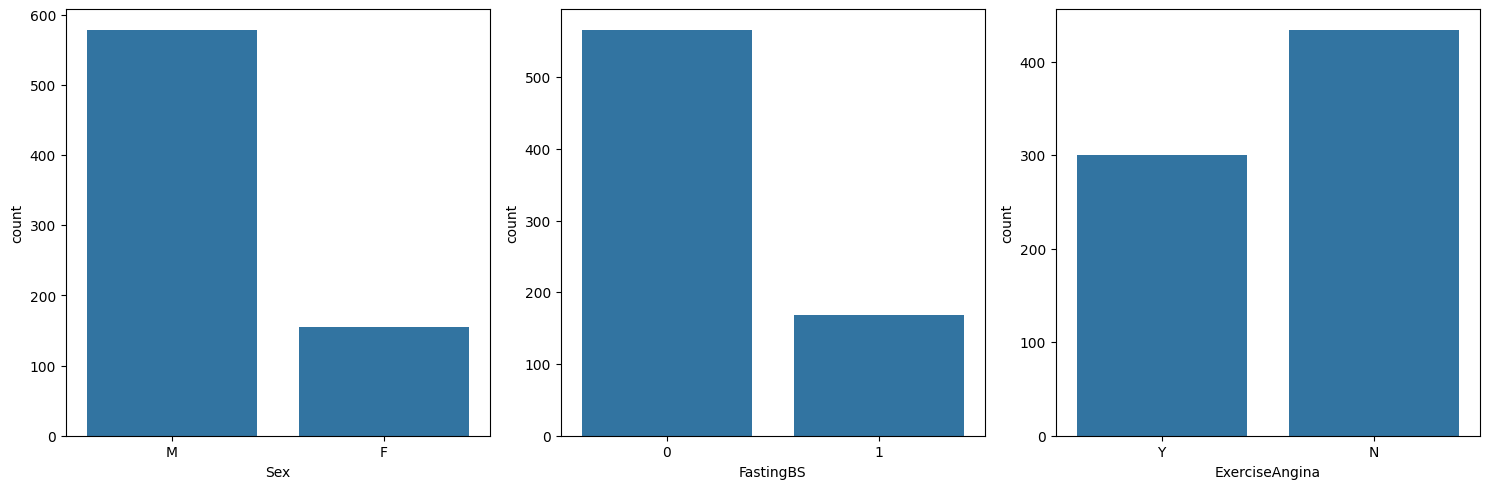

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.countplot(data=x_train, x='Sex', ax=axes[0])
sns.countplot(data=x_train, x='FastingBS', ax=axes[1])
sns.countplot(data=x_train, x='ExerciseAngina', ax=axes[2])

plt.tight_layout()
plt.show()

In [12]:
x_train[binary_cols].isnull().sum() 

Sex               0
FastingBS         0
ExerciseAngina    0
dtype: int64

Нулевых значений нет, значит сразу начнем обработку (т.е. переведем все значения в 0/1)

Теперь

для Sex: M - 1; F - 0; (т.е. 1 - мужчина, 0 - женщина)

для ExerciseAngina: Y - 1; N - 0; (1 - есть стенокардия; 0 - нет ее)

In [29]:
x_train.Sex = x_train.Sex.map({'M':1, "F" : 0})
x_train.ExerciseAngina = x_train.ExerciseAngina.map({'Y':1, "N" : 0})
x_train[binary_cols]

,Sex,FastingBS,ExerciseAngina
485,1,1,1
486,1,1,0
117,0,1,1
361,1,0,1
296,1,1,1
...,...,...,...
276,1,0,0
201,1,0,0
462,1,0,1
252,1,0,1


## Обработка числовых признаков

In [30]:
numeric_cols = [col for col in x_train.columns if x_train[col].dtype in ["int64", "float64"]]
x_train[numeric_cols]

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak
485,63,1,139,217,1,128,1,1.2
486,55,1,110,214,1,180,0,0.4
117,59,0,130,338,1,130,1,1.5
361,47,1,160,0,0,124,1,0.0
296,50,1,145,0,1,139,1,0.7
...,...,...,...,...,...,...,...,...
276,51,1,135,160,0,150,0,2.0
201,46,1,120,230,0,150,0,0.0
462,59,1,122,233,0,117,1,1.3
252,61,1,125,292,0,115,1,0.0


In [31]:
numeric_cols.remove('FastingBS') #удалим случайно попавштийся бинарный признак

In [32]:
x_train[numeric_cols]

,Age,Sex,RestingBP,Cholesterol,MaxHR,ExerciseAngina,Oldpeak
485,63,1,139,217,128,1,1.2
486,55,1,110,214,180,0,0.4
117,59,0,130,338,130,1,1.5
361,47,1,160,0,124,1,0.0
296,50,1,145,0,139,1,0.7
...,...,...,...,...,...,...,...
276,51,1,135,160,150,0,2.0
201,46,1,120,230,150,0,0.0
462,59,1,122,233,117,1,1.3
252,61,1,125,292,115,1,0.0


Серьзной корреляци между числовыми признаками нет. Можно не беспокоится

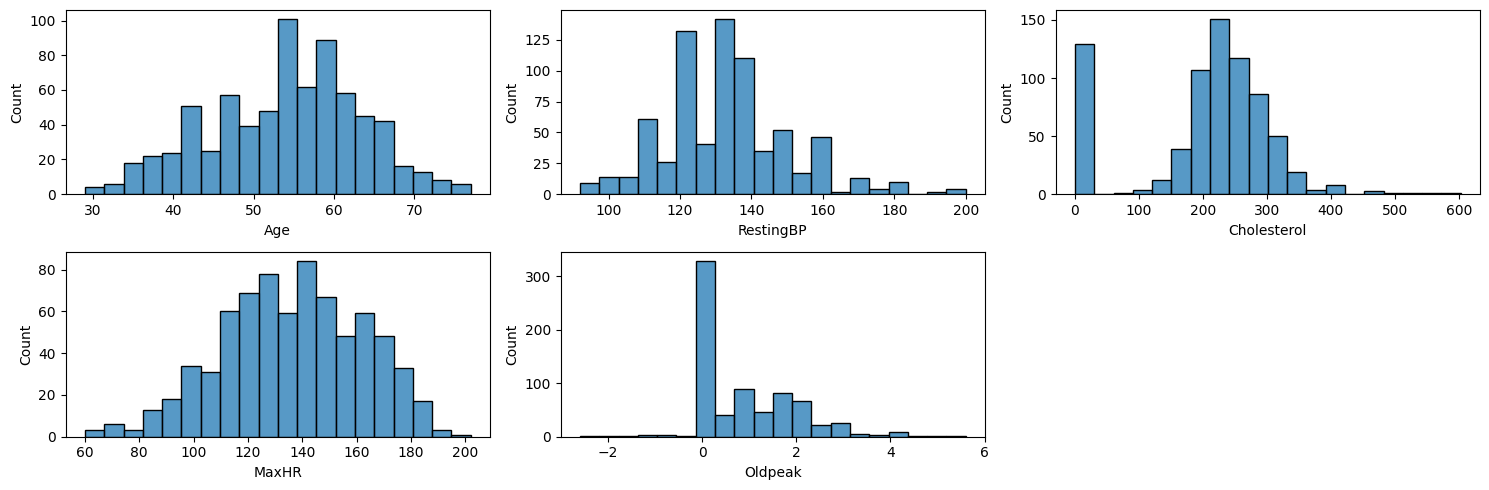

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15,5))
axes = axes.flatten()

sns.histplot(data=x_train, x='Age', bins=20, ax=axes[0])
sns.histplot(data=x_train, x='RestingBP', bins=20, ax=axes[1])
sns.histplot(data=x_train, x='Cholesterol', bins=20, ax=axes[2])
sns.histplot(data=x_train, x='MaxHR', bins=20, ax=axes[3])
sns.histplot(data=x_train, x='Oldpeak', bins=20, ax=axes[4])

axes[5].remove()

plt.tight_layout()
plt.show()

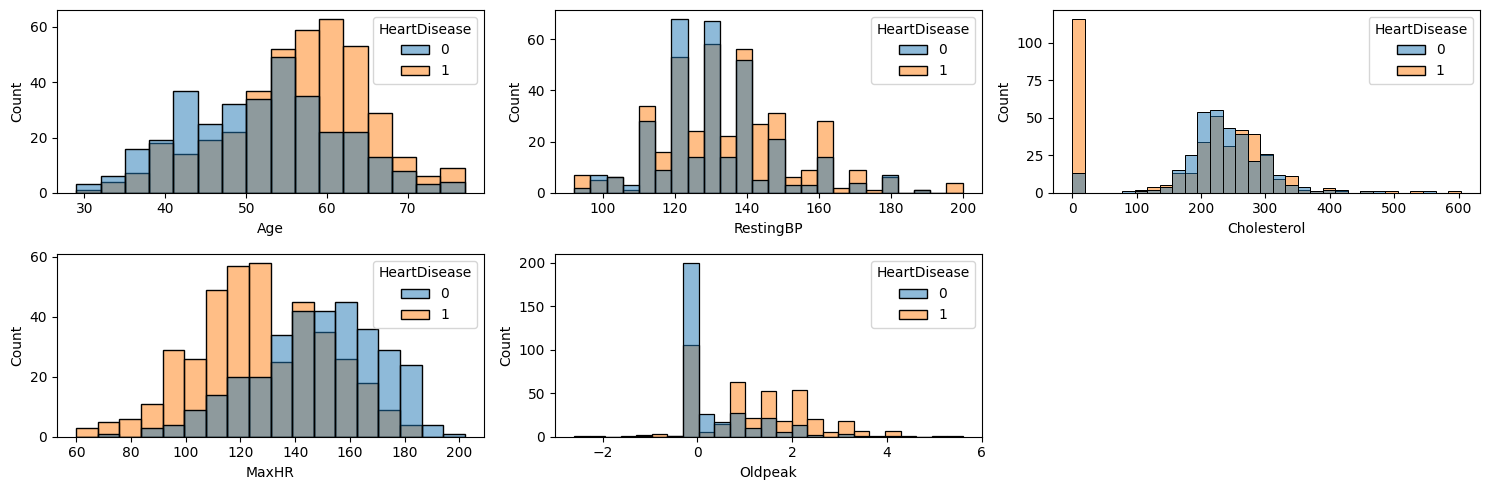

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15,5))
axes = axes.flatten()

sns.histplot(data=x_train, x='Age', hue=y_train, ax = axes[0])
sns.histplot(data=x_train, x='RestingBP', hue=y_train, ax = axes[1])
sns.histplot(data=x_train, x='Cholesterol', hue=y_train, ax = axes[2])
sns.histplot(data=x_train, x='MaxHR', hue=y_train, ax = axes[3])
sns.histplot(data=x_train, x='Oldpeak', hue=y_train, ax = axes[4])

axes[5].remove()

plt.tight_layout()
plt.show()

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_processed[numeric_cols] = scaler.fit_transform(x_train[numeric_cols])



## Обработка категориальных признаков

In [34]:
categorical_cols = [
    col for col in x_train.columns 
 if x_train[col].dtype == "object" and x_train[col].nunique()>2 
]
categorical_cols

['ChestPainType', 'RestingECG', 'ST_Slope']

In [ ]:
x_train[categorical_cols].isnull().sum() #нулевых нет

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.countplot(data=x_train, x='ChestPainType', ax=axes[0])
sns.countplot(data=x_train, x='RestingECG', ax=axes[1])
sns.countplot(data=x_train, x='ST_Slope', ax=axes[2])

plt.tight_layout()
plt.show()

Так, все категориальные признаки как заявлены. При этом все номинальные => стоит использовать One-Hot encoding

In [35]:
from sklearn.preprocessing import OneHotEncoder

one_hot_encoder = OneHotEncoder(handle_unknown='ignore')
encoded = one_hot_encoder.fit_transform(x_train[categorical_cols])

encoded_df = pd.DataFrame(
    encoded.toarray(),
    columns=one_hot_encoder.get_feature_names_out(categorical_cols),
    index=x_train.index
)
encoded_df



,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
485,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
486,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
117,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
361,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
296,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
276,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
201,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
462,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
252,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [36]:
x_train_numeric = x_train.drop(columns=categorical_cols)
x_train_processed  = pd.concat([x_train_numeric, encoded_df], axis=1)
x_train_processed

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
485,63,1,139,217,1,128,1,1.2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
486,55,1,110,214,1,180,0,0.4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
117,59,0,130,338,1,130,1,1.5,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
361,47,1,160,0,0,124,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
296,50,1,145,0,1,139,1,0.7,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276,51,1,135,160,0,150,0,2.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
201,46,1,120,230,0,150,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
462,59,1,122,233,0,117,1,1.3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
252,61,1,125,292,0,115,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [37]:
one_hot_encoder.get_feature_names_out()

array(['ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal',
       'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype=object)

In [ ]:
x_train

## Анализ целевой переменной

In [ ]:
y_train.value_counts() #данные сбалансированы - 328/406

## Корреляционный анализ 

In [ ]:
corr = x_train[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [ ]:
x_train[binary_cols].corr() #не коррелируют 


In [ ]:
x_train_processed

## Обработка x_test

In [39]:
x_test.Sex = x_test.Sex.map({'M':1, "F" : 0})
x_test.ExerciseAngina = x_test.ExerciseAngina.map({'Y':1, "N" : 0})



In [40]:
x_test_scaled = x_test.copy()
x_test_scaled[numeric_cols] = scaler.transform(x_test[numeric_cols])

In [41]:
# 2. кодируем категориальные признаки
encoded_test = one_hot_encoder.transform(x_test[categorical_cols]).toarray()

# 3. делаем DataFrame из one-hot признаков
encoded_test_df = pd.DataFrame(
    encoded_test,
    columns=one_hot_encoder.get_feature_names_out(categorical_cols),
    index=x_test.index
)

# 4. убираем старые категориальные признаки
x_test_numeric = x_test_scaled.drop(columns=categorical_cols)

# 5. объединяем
x_test_processed = pd.concat([x_test_numeric, encoded_test_df], axis=1)

In [42]:
x_test_processed

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
356,-0.831954,0.51740,-0.989299,-1.876035,0,-0.905584,1.202775,0.601071,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
763,0.440022,0.51740,-0.048409,0.191755,0,1.418673,-0.831411,2.210549,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
817,0.652018,0.51740,-0.435834,0.505616,0,0.179069,1.202775,1.831848,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
735,-0.513960,0.51740,-0.712567,-0.140568,0,0.101594,-0.831411,1.074447,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
892,-1.573940,-1.93274,0.283669,0.154830,0,0.605183,-0.831411,-0.819056,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52,-0.937952,0.51740,0.394362,0.191755,1,-0.556946,-0.831411,-0.819056,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
752,0.228026,0.51740,-0.435834,0.422535,1,0.295282,1.202775,0.317046,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
492,-0.513960,0.51740,-0.159102,-1.876035,0,0.334020,-0.831411,2.021198,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
622,0.546020,0.51740,-1.266031,0.330223,0,0.217807,1.202775,0.317046,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


<a id = "6" ></a>
# <span style="font-family:serif; font-size:28px;"> 3. Обучение модели </span>
<a id = "Undertanding the data" ></a>

## NON_TREE BASED алгоритмы

In [43]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier


In [ ]:

params = {
        "n_neighbors" : [3, 5, 7, 9, 11],
        "weights" : ["uniform", "distance"],
        "metric" : ["euclidean", "manhattan"]
    }

grid = GridSearchCV(KNeighborsClassifier(), params, cv=5)
grid.fit(x_train_processed, y_train)
#KNeighborsClassifier(metric='manhattan', n_neighbors=9, weights='distance')


In [ ]:
knn_model = KNeighborsClassifier(
    n_neighbors=9, 
    weights='distance',
    metric='manhattan',
)

knn_model.fit(x_train_processed, y_train)
predicted_y = knn_model.predict(x_test_processed)
accuracy_knn = knn_model.score(x_test_processed, y_test)
accuracy_knn

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predicted_y))

In [ ]:
from sklearn.svm import SVC

params = {
    "C": [0.1, 1, 10],
    "kernel" : ["linear", "rbf"], 
    "gamma" : ["scale", "auto"]
}

grid = GridSearchCV(SVC(), params, cv = 5)

grid.fit(x_train_processed, y_train)


In [ ]:
grid.best_estimator_.get_params()

In [ ]:
svc_model = SVC(
   C=1
)

svc_model.fit(x_train_processed, y_train)
predict_y = svc_model.predict(x_test_processed)
accuracy_svc = svc_model.score(x_test_processed, y_test)
accuracy_svc

In [ ]:
print(classification_report(y_test, predict_y))

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,roc_auc_score

params =  {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
    "class_weight": [None, "balanced"]
}


grid = GridSearchCV(LogisticRegression(), params, cv = 5, scoring="roc_auc")

grid.fit(x_train_processed, y_train)

#(C=1, penalty='l1', solver='liblinear')

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'class_weight': [None, 'balanced'],
                         'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
             scoring='roc_auc')

In [45]:
logistic_model = LogisticRegression(C=1, penalty='l1', solver='liblinear')


logistic_model.fit(x_train_processed, y_train)
predict_y = logistic_model.predict(x_test_processed)
accuracy_svc = logistic_model.score(x_test_processed, y_test)
accuracy_svc

0.8804347826086957

## TREE BASED алгоритмы

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

params = {
    "max_depth" : [3,5,7,10, None],
    "min_samples_split" : [2, 5, 10, 20],
    "min_samples_leaf" : [1, 2, 5, 10],
    "criterion" : ["gini", "entropy", "log_loss"],
    "max_features" : [None, "sqrt", "log2"]
}
grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=params, 
    cv=5,
    scoring="f1",
    n_jobs=-1,
    error_score=np.nan
)

grid.fit(x_train_processed, y_train)

In [20]:
decision_tree_model = DecisionTreeClassifier(
criterion='entropy', max_depth=7, max_features='sqrt',
                       min_samples_split=20, random_state=42
)

decision_tree_model.fit(x_train_processed, y_train)
predict_y = decision_tree_model.predict(x_test_processed)
accuracy_svc = decision_tree_model.score(x_test_processed, y_test)
accuracy_svc

NameError: name 'DecisionTreeClassifier' is not defined

In [47]:
from sklearn.ensemble import RandomForestClassifier

params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=params, 
    cv=5, # количество фолдов
    scoring="roc_auc",
    n_jobs=-1, #сколько ядер процессора использовать
    error_score=np.nan
)


grid.fit(x_train_processed, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300, 500]},
             scoring='roc_auc')

In [49]:
rm_model = RandomForestClassifier(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                       n_estimators=500, random_state=42)


rm_model.fit(x_train_processed, y_train)
predict_y = rm_model.predict(x_test_processed)
accuracy_svc = rm_model.score(x_test_processed, y_test)
accuracy_svc

0.8695652173913043

In [50]:
rm_model.score(x_train_processed, y_train)


0.9196185286103542